In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('IPL.csv')

In [4]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


## Basic information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

In [6]:
print(f"rows are {df.shape[0]} and columns are {df.shape[1]}")

rows are 74 and columns are 20


In [7]:
print(df.isnull().count())     # counts non nan values
print("using len function",len(df.isnull()))  # counts no. of rows, answer similar to count
print("using sum function",df.isnull().sum())  # counts true values only

match_id               74
date                   74
venue                  74
team1                  74
team2                  74
stage                  74
toss_winner            74
toss_decision          74
first_ings_score       74
first_ings_wkts        74
second_ings_score      74
second_ings_wkts       74
match_winner           74
won_by                 74
margin                 74
player_of_the_match    74
top_scorer             74
highscore              74
best_bowling           74
best_bowling_figure    74
dtype: int64
using len function 74
using sum function match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
h

### 1.Which team won the most matches

In [8]:
match_wins = df['match_winner'].value_counts()
match_wins

match_winner
Gujarat      12
Rajasthan    10
Banglore      9
Lucknow       9
Delhi         7
Punjab        7
Kolkata       6
Hyderabad     6
Chennai       4
Mumbai        4
Name: count, dtype: int64

Text(0.5, 1.0, 'Most matches won by team')

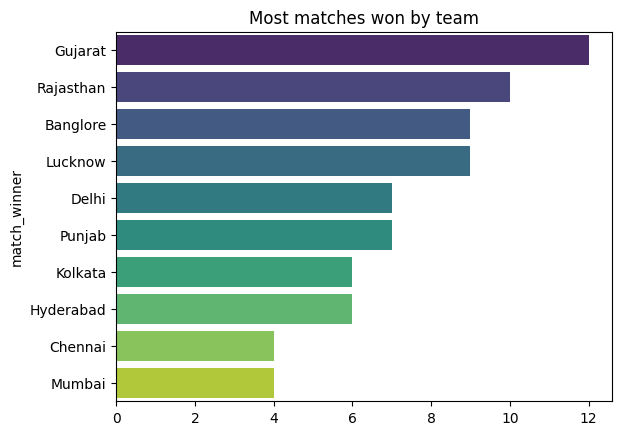

In [9]:
sns.barplot(y=match_wins.index, x=match_wins.values,palette='viridis')
plt.title("Most matches won by team")

### 2.Toss decision trends

Text(0.5, 1.0, 'Toss Decision Trends')

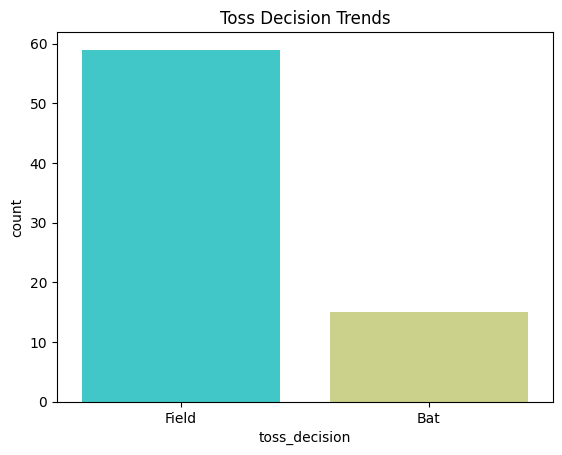

In [10]:
sns.countplot(x=df['toss_decision'],palette='rainbow')
plt.title("Toss Decision Trends")

### 3.Toss winner vs Match winner

In [11]:
count = len(df[df['toss_winner'] == df['match_winner']])
percentage = count/len(df)*100
percentage

48.64864864864865

### 4.How do teams win (Runs vs wickets)

In [12]:
df['won_by'].value_counts()   

won_by
Wickets    37
Runs       37
Name: count, dtype: int64

In [13]:
df.groupby('won_by')['match_id'].count()    # using grouby

won_by
Runs       37
Wickets    37
Name: match_id, dtype: int64

<Axes: xlabel='won_by', ylabel='count'>

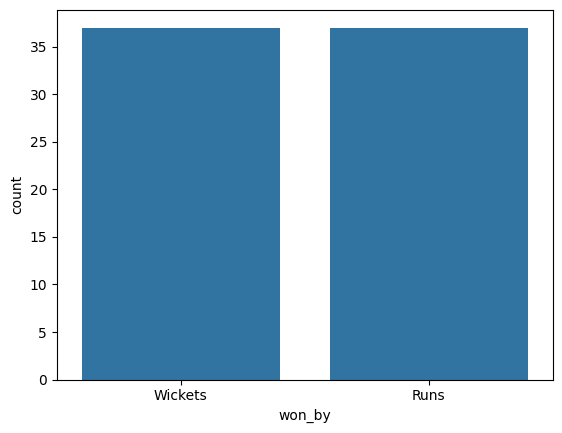

In [14]:
sns.countplot(x=df['won_by'])

# Key Player Performances

### 1.Most Player of the match award

In [15]:
count = df['player_of_the_match'].value_counts().head(10)    # top 10 players
count

player_of_the_match
Kuldeep Yadav      4
Jos Buttler        3
Umesh Yadav        2
Quinton de Kock    2
David Miller       2
Umran Malik        2
K L Rahul          2
Rahul Tripathi     2
Hardik Pandya      2
Jasprit Bumrah     2
Name: count, dtype: int64

Text(0.5, 1.0, 'Top 10 players with man of the match')

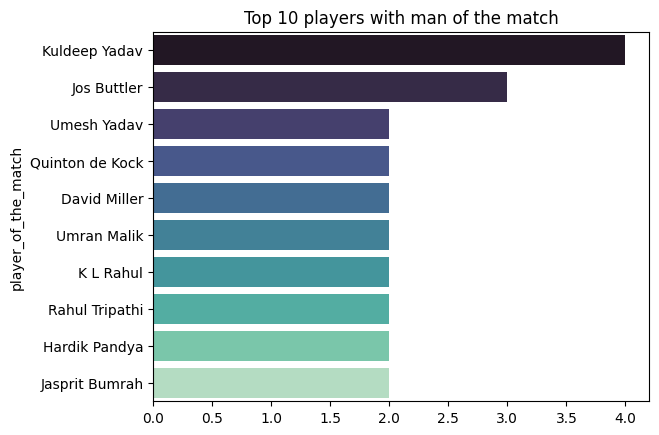

In [16]:
sns.barplot(y=count.index,x=count.values,palette='mako')
plt.title('Top 10 players with man of the match')

### 2.Two top scorers

In [17]:
df['top_scorer'].value_counts().head(2)

top_scorer
Jos Buttler        7
Quinton de Kock    5
Name: count, dtype: int64

In [31]:
high = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(2)
high
# here by using groupby we have calculated the total runs scored by top scorer

top_scorer
Jos Buttler        651
Quinton de Kock    377
Name: highscore, dtype: int64

<Axes: ylabel='top_scorer'>

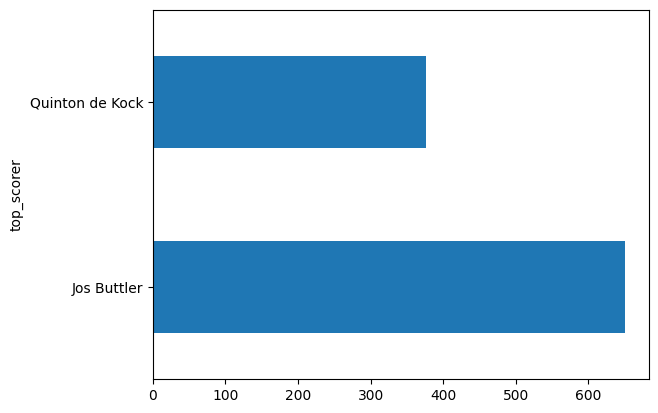

In [32]:
high.plot(kind='barh')

### 3.Ten best bowling figures

In [36]:
df['best_bowling_figure'].value_counts().head(10)

best_bowling_figure
3--22    5
3--20    3
2--23    3
3--25    3
2--24    3
3--19    2
3--28    2
3--30    2
3--23    2
4--30    2
Name: count, dtype: int64

In [ ]:
df['highest_wicket'] = df['best_bowling_figure'].apply(lambda x:x.split('--')[0]) 
# new column - 'highest_wicket
df['highest_wicket'] = df['highest_wicket'].astype(int) 
# because the data type of 'highest_wicket' is string and we have to apply sum function afterwards
df['highest_wicket']

0     3
1     3
2     2
3     3
4     3
     ..
69    3
70    1
71    3
72    3
73    3
Name: highest_wicket, Length: 74, dtype: int64

In [47]:
top_bowlers = df.groupby('best_bowling')['highest_wicket'].sum().sort_values(ascending=False).head(10)
top_bowlers

best_bowling
Yuzvendra Chahal     17
Kuldeep Yadav        11
Rashid Khan          11
Jasprit Bumrah       11
Avesh Khan           10
Josh Hazlewood       10
Kagiso Rabada        10
Wanindu Hasaranga     9
Umran Malik           9
T Natarajan           8
Name: highest_wicket, dtype: int64

<Axes: ylabel='best_bowling'>

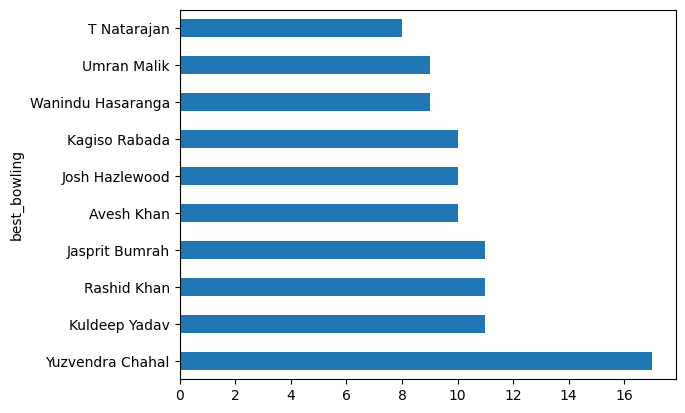

In [48]:
top_bowlers.plot(kind='barh')

# Venue Analysis

### 1.Most matches played by venue

In [49]:
df.head(2)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,highest_wicket
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,3
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,...,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18,3


In [51]:
venue_count = df['venue'].value_counts()
venue_count

venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

<Axes: ylabel='venue'>

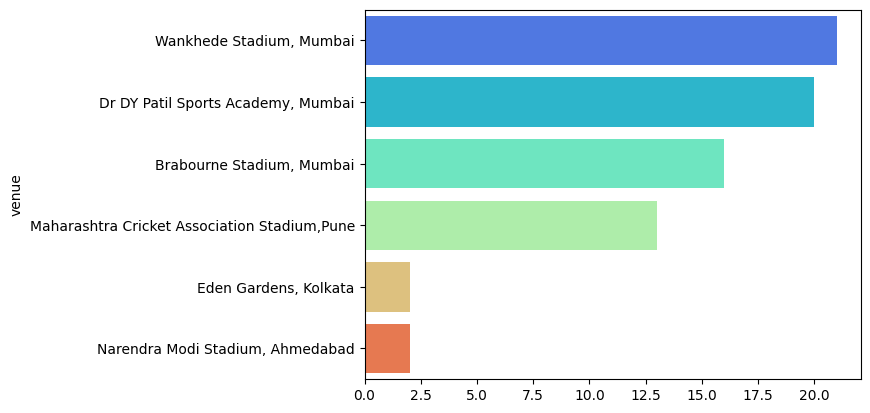

In [54]:
sns.barplot(x=venue_count.values, y=venue_count.index,palette='rainbow')

# Custom questions & insights

### Who won the highest margin by runs

In [55]:
df.head(2)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,highest_wicket
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,3
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,...,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18,3


In [69]:
df[df['won_by'] == 'Runs'].sort_values(by='margin',ascending=False).head(1)[['match_winner','won_by']]

,match_winner,won_by
54,Chennai,Runs


### 2.Which player had the highest individual score

In [73]:
df[df['highscore'] == df['highscore'].max()][['top_scorer','highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


### Which bowler had the best bowling figures

In [76]:
df[df['highest_wicket'] == df['highest_wicket'].max()][['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
